In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Nayka_Cleaned.csv")
df

,Product Name,Original Price,Offer Price,Discount %,Reviews,Images Links,Product Category
0,Orimii Bump Hydrating Body Butter for Reducing...,695,660,5,96,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products
1,Cetaphil Moisturising Cream,899,746,17,146238,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products
2,CeraVe Moisturizer Cream For Dry Skin With Cer...,430,409,5,41480,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products
3,Cetaphil Moisturising Lotion,789,655,17,193928,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products
4,Wishcare 10% AHA Blend + 1% Salicylic Acid Gly...,499,399,20,6701,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products
...,...,...,...,...,...,...,...
34352,IDUN Minerals Eye & Lip Definer Brush,1300,1300,0,0,Link Not Available,Tools_and_Brushes
34353,IDUN Minerals Precision Eyeshadow Brush,800,800,0,0,Link Not Available,Tools_and_Brushes
34354,IDUN Minerals Powder Brush,2900,2900,0,0,Link Not Available,Tools_and_Brushes
34355,IDUN Minerals Concealer Brush,1300,1300,0,0,Link Not Available,Tools_and_Brushes


# 1. Univariate Analysis

In [7]:
# Summary statistics
print(df['Original Price'].describe())

count     34357.000000
mean       1827.381902
std        3792.261967
min           0.000000
25%         395.000000
50%         700.000000
75%        1699.000000
max      159900.000000
Name: Original Price, dtype: float64


In [8]:
# Summary statistics
print(df['Discount %'].describe())

count    34357.000000
mean        13.389266
std         14.780743
min          0.000000
25%          0.000000
50%         10.000000
75%         20.000000
max         88.000000
Name: Discount %, dtype: float64


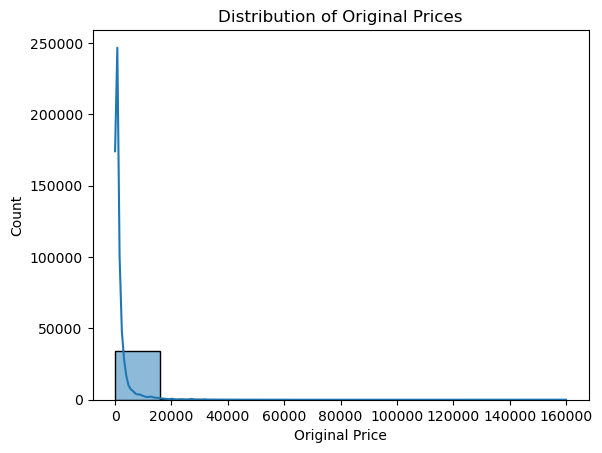

In [9]:
# Product Price Distribution
# Histogram
sns.histplot(df['Original Price'], bins=10, kde=True)
plt.title("Distribution of Original Prices")
plt.show()

In [10]:
# Most Nykaa products are priced below ₹1000, while few luxury products exceed ₹5000.

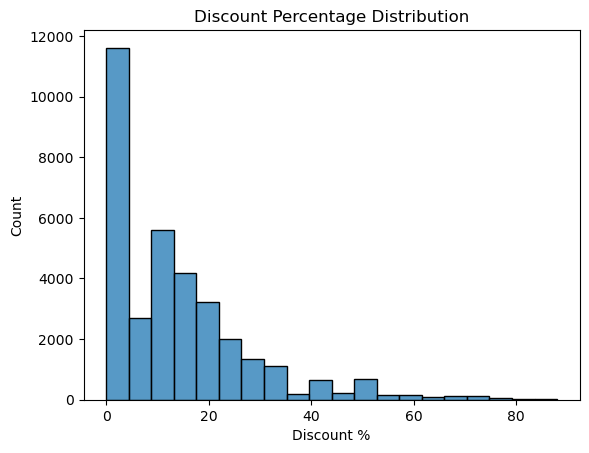

In [11]:
# Discount Percentage Analysis
sns.histplot(df['Discount %'], bins=20)
plt.title("Discount Percentage Distribution")
plt.show()

In [12]:
# Most products offer discounts between 10–30%

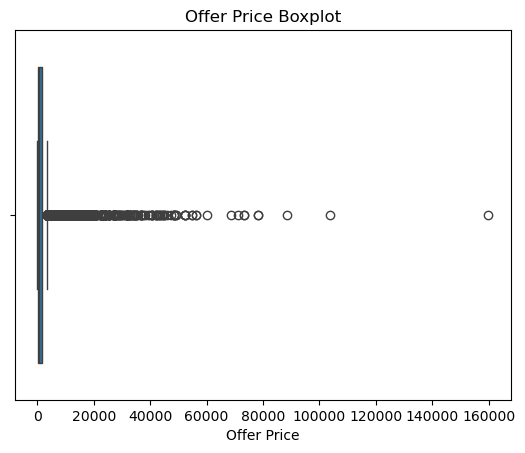

In [13]:
# Offer Price Analysis
# Boxplot
sns.boxplot(x=df['Offer Price'])
plt.title("Offer Price Boxplot")
plt.show()

In [14]:
# Majority of discounted products are sold between ₹300–₹1200.

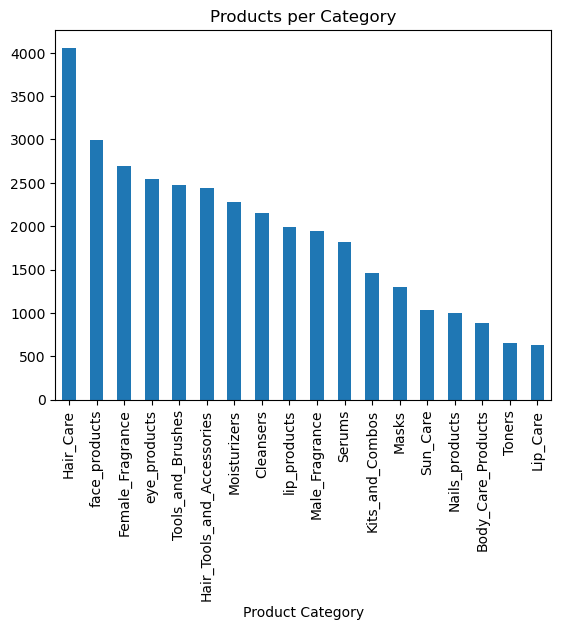

In [15]:
# Product Category Frequency
df['Product Category'].value_counts().plot(kind='bar')
plt.title("Products per Category")
plt.show()

In [16]:
# Hair care contain the highest number of products.

# 2. Bivariate Analysis

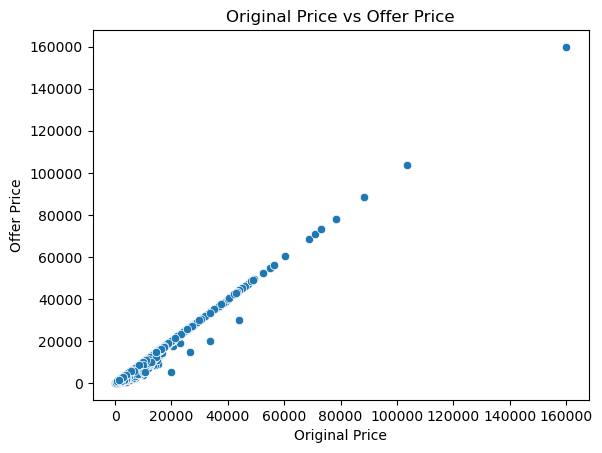

In [17]:
# Original Price vs Offer Price
# Scatterplot
sns.scatterplot(x=df['Original Price'], y=df['Offer Price'])
plt.title("Original Price vs Offer Price")
plt.show()

In [18]:
# Offer price increases proportionally with original price.

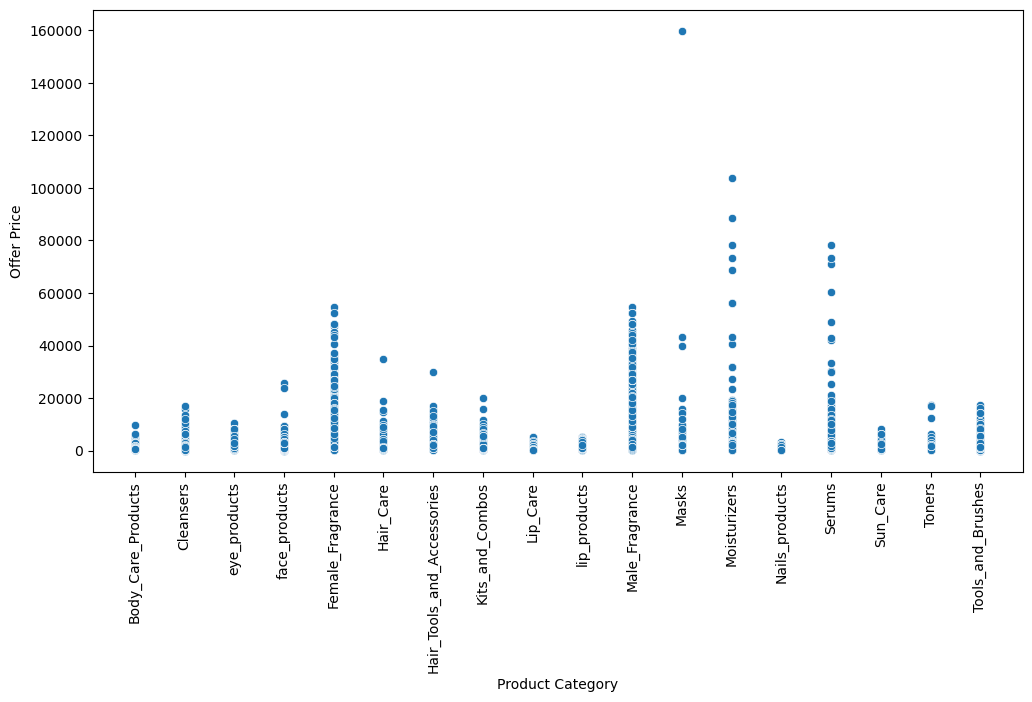

In [19]:
# Product Category vs Offer Price
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df['Product Category'],
    y=df['Offer Price']
)

plt.xticks(rotation=90)
plt.show()

In [20]:
# Categories like moisturizers, serums, and fragrances have significantly higher median prices 

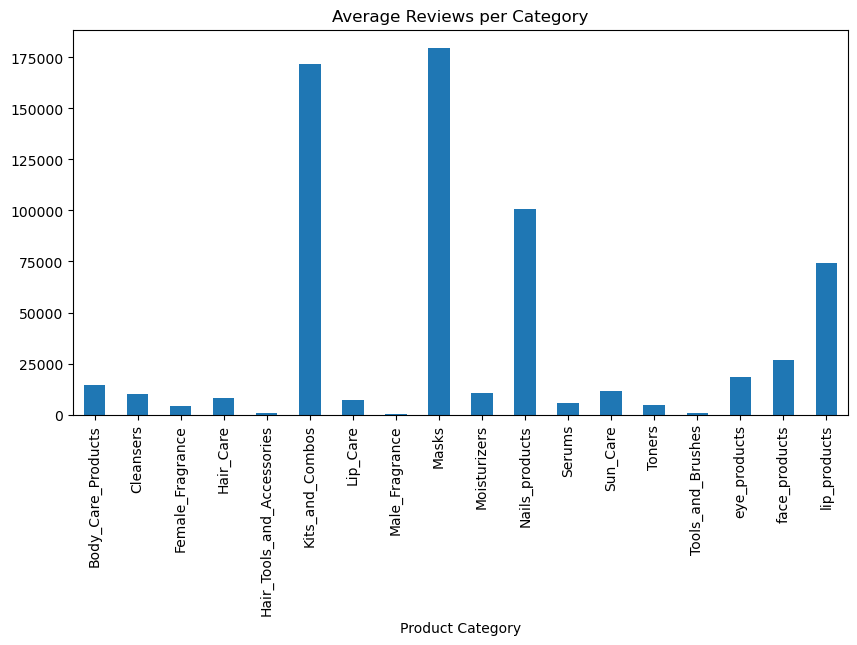

In [21]:
# Product Category vs Reviews
plt.figure(figsize=(10,5))
category_reviews = df.groupby('Product Category')['Reviews'].mean()

category_reviews.plot(kind='bar')
plt.title("Average Reviews per Category")
plt.show()

In [22]:
# masks and kits and combos receive the highest average customer reviews

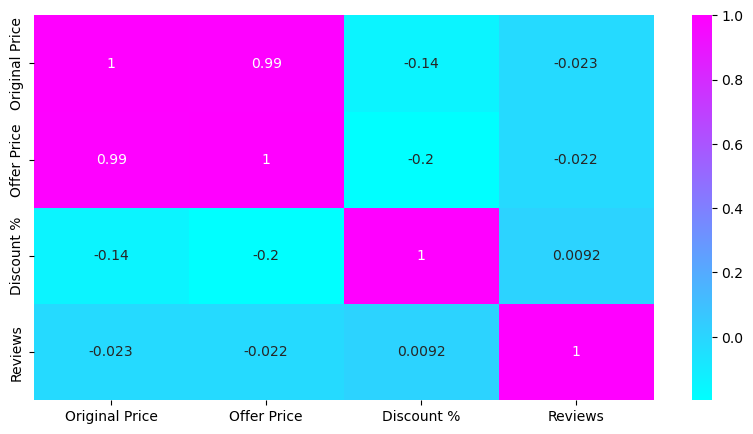

In [23]:
# Correlation Analysis
plt.figure(figsize=(10,5))
corr = df[['Original Price','Offer Price','Discount %','Reviews']].corr()

sns.heatmap(corr, annot=True, cmap='cool')
plt.show()

In [24]:
# Original Price and Offer Price show strong positive correlation

# 3. Multivariate Analysis

In [36]:
# Category + Discount + Reviews
grouped = df.groupby('Product Category')[['Discount %','Reviews']].max()
grouped

,Discount %,Reviews
Product Category,,
Body_Care_Products,85,905833
Cleansers,76,872609
Female_Fragrance,79,1795504
Hair_Care,70,783174
Hair_Tools_and_Accessories,88,872609
Kits_and_Combos,76,10787710
Lip_Care,60,905910
Male_Fragrance,79,126533
Masks,78,7985126


In [26]:
# Categories offering higher discounts generally receive higher customer engagement.

In [27]:
# Pairplot Analysis

# sns.pairplot(
#    df[['Original Price','Offer Price','Discount %','Reviews']]
#)

#plt.show()


KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x0000028FC98B44A0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x0000028FCBBEE3E0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# Shows relationships between ALL numerical columns together.

In [35]:
# Category-wise Price & Discount Analysis
category_analysis = df.groupby('Product Category')[
    ['Original Price','Offer Price','Discount %']
].mean()

category_analysis

,Original Price,Offer Price,Discount %
Product Category,,,
Body_Care_Products,838.332579,730.376697,14.920814
Cleansers,862.876687,779.898092,12.951140
Female_Fragrance,5591.058321,5160.041605,15.424220
Hair_Care,1089.328818,985.539901,11.382266
Hair_Tools_and_Accessories,1247.108285,977.743642,18.251846
Kits_and_Combos,1512.319672,1292.896175,15.894126
Lip_Care,743.808612,686.653907,10.098884
Male_Fragrance,6079.430990,5578.276552,17.189841
Masks,941.605873,869.846986,13.404173


In [34]:
# Top Reviewed Products
top_products = df.sort_values(
    by=['Reviews','Offer Price'],
    ascending=False
)

top_products.head(10)

,Product Name,Original Price,Offer Price,Discount %,Reviews,Images Links,Product Category
18051,"Nykaa Cosmetics Set Of 5-Black Licorice,Blackc...",945,804,15,10787710,Link Not Available,Kits_and_Combos
27525,"Nykaa Cosmetics Set Of 5-Black Licorice,Blackc...",945,804,15,10787710,Link Not Available,Nails_products
27380,Nykaa Cosmetics Nail Enamel,189,132,30,10787709,Link Not Available,Nails_products
18012,Maybelline New York Power of Mattes Combo,1078,1078,0,10776241,Link Not Available,Kits_and_Combos
20681,Maybelline New York Power of Mattes Combo,1078,1078,0,10776241,Link Not Available,lip_products
4879,Elle 18 Bestsellers Combo,415,374,10,8714008,Link Not Available,eye_products
18636,Elle 18 Bestsellers Combo,415,374,10,8714008,Link Not Available,Kits_and_Combos
18052,Elle 18 Nail Pops 1 - Pack of 5,325,293,10,8601426,Link Not Available,Kits_and_Combos
27526,Elle 18 Nail Pops 1 - Pack of 5,325,293,10,8601426,Link Not Available,Nails_products
17958,Elle 18 Chip Resistant Nail Polish Set,390,351,10,8601418,Link Not Available,Kits_and_Combos


# EDA Questions - 

## 1. Top 10 Most Expensive Products

In [37]:
top_expensive = df.sort_values(
    by='Original Price',
    ascending=False
)
top_expensive[
    ['Product Name','Original Price']
].head(10)

,Product Name,Original Price
24509,La Prairie Platinum Rare Haute-Rejuvenation Fa...,159900
26355,La Prairie Platinum Rare Haute-Rejuvenation Fa...,103600
26616,La Prairie Pure Gold Radiance Cream,88400
29338,La Prairie Skin Caviar Harmony L’extrait Light...,78200
26395,La Prairie White Caviar Crème Extraordinaire I...,78200
26971,La Prairie Platinum Rare Haute-Rejuvenation Ce...,73200
29768,La Prairie Platinum Rare Haute-Rejuvenation Ce...,73200
29091,La Prairie White Caviar Pearl Infusion Serum,71000
27030,La Prairie Skin Caviar Absolute Filler Volume-...,68700
29806,La Prairie White Caviar Light Concentrate,60200


## 2. Top 10 Most Reviewed Products

In [38]:
top_reviewed = df.sort_values(
    by='Reviews',
    ascending=False
)

top_reviewed[
    ['Product Name','Reviews']
].head(10)

,Product Name,Reviews
18051,"Nykaa Cosmetics Set Of 5-Black Licorice,Blackc...",10787710
27525,"Nykaa Cosmetics Set Of 5-Black Licorice,Blackc...",10787710
27380,Nykaa Cosmetics Nail Enamel,10787709
18012,Maybelline New York Power of Mattes Combo,10776241
20681,Maybelline New York Power of Mattes Combo,10776241
18636,Elle 18 Bestsellers Combo,8714008
4879,Elle 18 Bestsellers Combo,8714008
18052,Elle 18 Nail Pops 1 - Pack of 5,8601426
27526,Elle 18 Nail Pops 1 - Pack of 5,8601426
27492,Elle 18 Chip Resistant Nail Polish Set,8601418


## 3. Discount Effectiveness Analysis

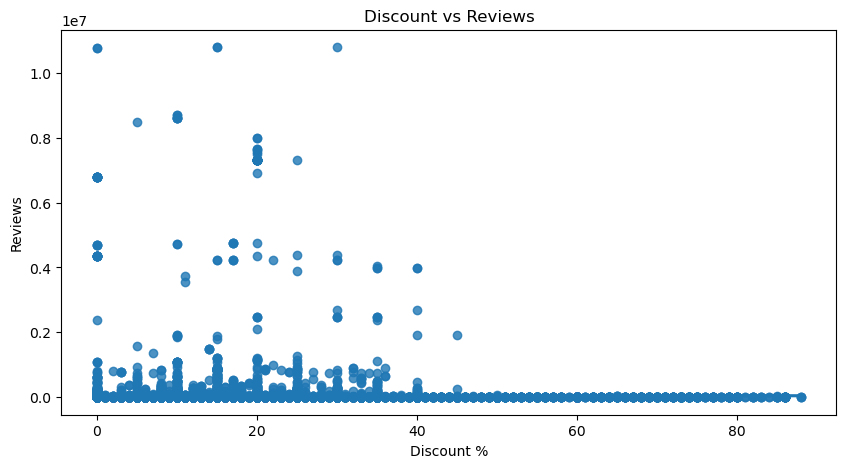

In [40]:
plt.figure(figsize=(10,5))
sns.regplot(
    x=df['Discount %'],
    y=df['Reviews']
)

plt.title("Discount vs Reviews")
plt.show()

In [ ]:
# Weak trend → discounts don't strongly impact popularity.

## 4. Profit Margin Approximation

In [41]:
df['Price Difference'] = (
    df['Original Price']
    - df['Offer Price']
)

print(df['Price Difference'].describe())

count    34357.000000
mean       165.979946
std        412.789434
min          0.000000
25%          0.000000
50%         48.000000
75%        144.000000
max      14991.000000
Name: Price Difference, dtype: float64


## 5. Category-wise Average Discount

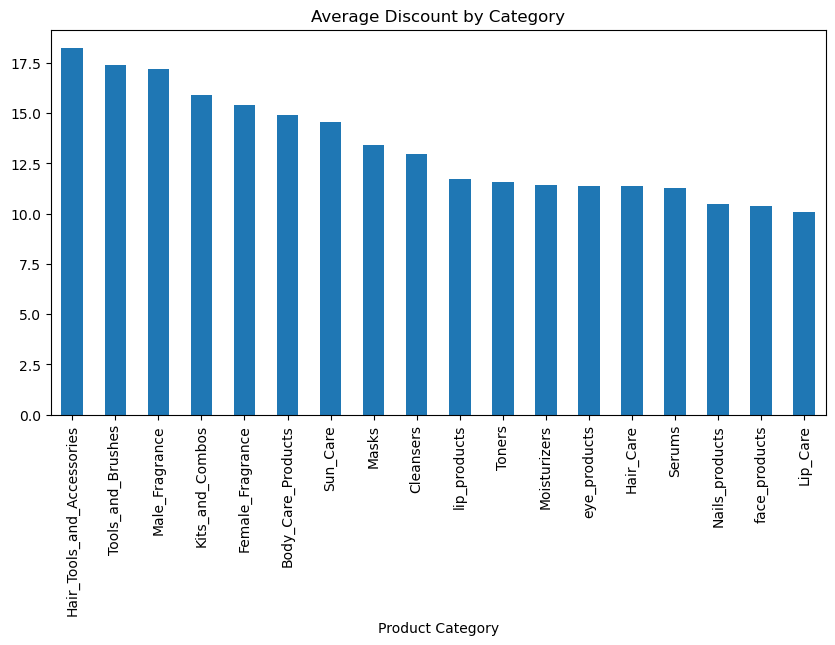

In [43]:
plt.figure(figsize=(10,5))
avg_discount = df.groupby(
    'Product Category'
)['Discount %'].mean()

avg_discount.sort_values(
    ascending=False
).plot(kind='bar')

plt.title("Average Discount by Category")
plt.show()

## 6. Category-wise Revenue Potential

In [45]:
revenue = df.groupby(
    'Product Category'
)[['Offer Price','Reviews']].mean()

revenue

,Offer Price,Reviews
Product Category,,
Body_Care_Products,730.376697,14606.199095
Cleansers,779.898092,10205.417869
Female_Fragrance,5160.041605,4229.469168
Hair_Care,985.539901,8035.187685
Hair_Tools_and_Accessories,977.743642,672.083265
Kits_and_Combos,1292.896175,171990.400273
Lip_Care,686.653907,7373.496013
Male_Fragrance,5578.276552,159.159569
Masks,869.846986,179618.639876


## 7. Outlier Detection

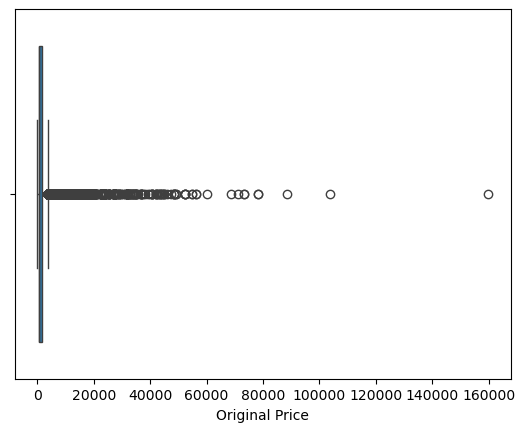

In [46]:
sns.boxplot(x=df['Original Price'])
plt.show()

## 8. Category Product Count Analysis

In [49]:
category_count = df[
    'Product Category'
].value_counts()

category_count

Product Category
Hair_Care                     4060
face_products                 2999
Female_Fragrance              2692
eye_products                  2542
Tools_and_Brushes             2479
Hair_Tools_and_Accessories    2438
Moisturizers                  2278
Cleansers                     2149
lip_products                  1994
Male_Fragrance                1949
Serums                        1819
Kits_and_Combos               1464
Masks                         1294
Sun_Care                      1032
Nails_products                1000
Body_Care_Products             884
Toners                         657
Lip_Care                       627
Name: count, dtype: int64

## 9. Customer Engagement Analysis

In [50]:
df['Engagement Level'] = pd.cut(
    df['Reviews'],
    bins=[0,50,500,5000,100000],
    labels=[
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

print(
    df['Engagement Level']
    .value_counts()
)

Engagement Level
Low          13961
Medium        6652
High          4236
Very High     2447
Name: count, dtype: int64


## 10. Price Range Segmentation

In [100]:
df['Price Segment'] = pd.cut(
    df['Offer Price'],
    bins=[0,1000,3000,10000,200000],
    labels=[
        'Low-Range',
        'Mid-Range',
        'High-Range',
        'Premium'
    ]
)

df['Price Segment'].value_counts()
df


,Product Name,Original Price,Offer Price,Discount %,Reviews,Images Links,Product Category,Price Segment
0,Orimii Bump Hydrating Body Butter for Reducing...,695,660,5,96,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
1,Cetaphil Moisturising Cream,899,746,17,146238,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
2,CeraVe Moisturizer Cream For Dry Skin With Cer...,430,409,5,41480,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
3,Cetaphil Moisturising Lotion,789,655,17,193928,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
4,Wishcare 10% AHA Blend + 1% Salicylic Acid Gly...,499,399,20,6701,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
...,...,...,...,...,...,...,...,...
34352,IDUN Minerals Eye & Lip Definer Brush,1300,1300,0,0,Link Not Available,Tools_and_Brushes,Mid-Range
34353,IDUN Minerals Precision Eyeshadow Brush,800,800,0,0,Link Not Available,Tools_and_Brushes,Low-Range
34354,IDUN Minerals Powder Brush,2900,2900,0,0,Link Not Available,Tools_and_Brushes,Mid-Range
34355,IDUN Minerals Concealer Brush,1300,1300,0,0,Link Not Available,Tools_and_Brushes,Mid-Range


## 11. Correlation Matrix Analysis

                Original Price  Offer Price  Discount %   Reviews
Original Price        1.000000     0.994116   -0.141452 -0.022630
Offer Price           0.994116     1.000000   -0.197479 -0.021745
Discount %           -0.141452    -0.197479    1.000000  0.009232
Reviews              -0.022630    -0.021745    0.009232  1.000000


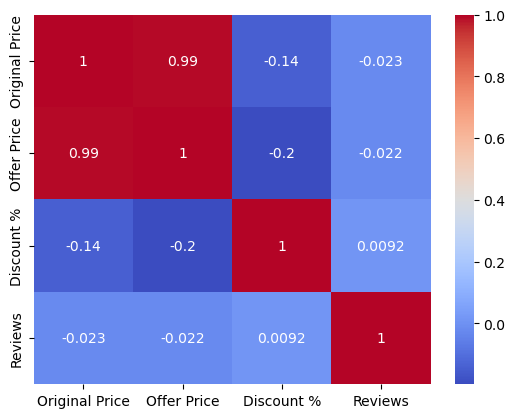

In [53]:
corr = df[
    ['Original Price',
     'Offer Price',
     'Discount %',
     'Reviews']
].corr()

print(corr)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

## 12. Distribution Skewness Analysis

In [56]:
print(
    df['Original Price'].skew()
)

8.845894521050472


## 13. Missing Value Analysis

In [57]:
print(df.isnull().sum())

Product Name           0
Original Price         0
Offer Price            0
Discount %             0
Reviews                0
Images Links           0
Product Category       0
Price Difference       0
Engagement Level    7061
Price Segment        980
dtype: int64


## 14. Most Discounted Products

In [61]:
high_discount = df.sort_values(
    by='Discount %',
    ascending=False
)


high_discount[['Product Name','Discount %']].head(10)

,Product Name,Discount %
17015,Fabula Gold Tone Filigree Lotus Hair Clip/Hair...,88
16126,OOMPH Jewellery Gold Tone Filigree Lotus Hair ...,88
16987,OOMPH Jewellery Gold Tone Large Leaf Motif Hai...,88
33535,Rhe Cosmetics Beauty Blender Makeup Sponge Tea...,86
32834,MAKEUP BY SITI Beauty Blender New Age Makeup S...,86
33161,MAKEUP BY SITI Beauty Blender New Age Makeup S...,86
33130,Rhe Cosmetics Beauty Blender Makeup Sponge Tea...,86
33128,Rhe Cosmetics Beauty Blender Makeup Sponge Cur...,86
33579,Rhe Cosmetics Beauty Blender Makeup Sponge Tea...,86
33219,Rhe Cosmetics Beauty Blender Makeup Sponge - O...,86


## 15. KDE Density Analysis

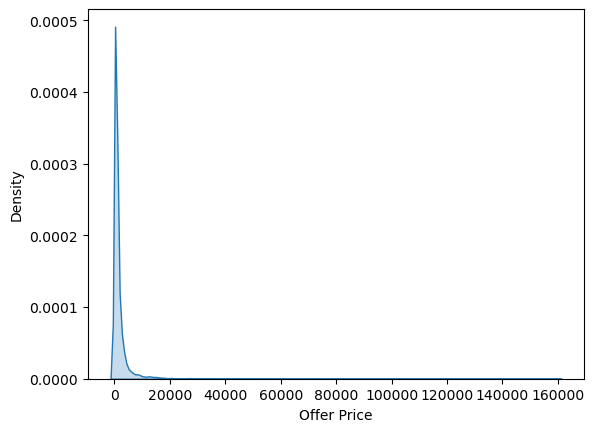

In [62]:
sns.kdeplot(
    df['Offer Price'],
    fill=True
)

plt.show()

## 16. Category-wise Median Price

In [65]:
median_price = df.groupby(
    'Product Category'
)['Offer Price'].median()

median_price

Product Category
Body_Care_Products             450.0
Cleansers                      356.0
Female_Fragrance              2080.0
Hair_Care                      584.0
Hair_Tools_and_Accessories     390.5
Kits_and_Combos                808.0
Lip_Care                       360.0
Male_Fragrance                2588.0
Masks                          319.0
Moisturizers                   664.5
Nails_products                 239.0
Serums                         775.0
Sun_Care                       564.0
Toners                         599.0
Tools_and_Brushes              394.0
eye_products                   550.0
face_products                  739.0
lip_products                   639.0
Name: Offer Price, dtype: float64

## 17. Category-wise Mean Price

In [102]:
mean_price = df.groupby(
    'Product Category'
)['Offer Price'].mean()

mean_price

Product Category
Body_Care_Products             730.376697
Cleansers                      779.898092
Female_Fragrance              5160.041605
Hair_Care                      985.539901
Hair_Tools_and_Accessories     977.743642
Kits_and_Combos               1292.896175
Lip_Care                       686.653907
Male_Fragrance                5578.276552
Masks                          869.846986
Moisturizers                  1805.497366
Nails_products                 441.460000
Serums                        1903.879054
Sun_Care                       926.435078
Toners                        1038.123288
Tools_and_Brushes              749.260992
eye_products                  1070.702203
face_products                 1313.079026
lip_products                   997.773821
Name: Offer Price, dtype: float64

In [97]:
df.drop('Log Price', axis=1, inplace = True)

In [ ]:
df.drop('Engagement Level', axis=1, inplace = True)

In [98]:
df.drop('Price Difference', axis=1, inplace = True)

In [101]:
df

,Product Name,Original Price,Offer Price,Discount %,Reviews,Images Links,Product Category,Price Segment
0,Orimii Bump Hydrating Body Butter for Reducing...,695,660,5,96,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
1,Cetaphil Moisturising Cream,899,746,17,146238,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
2,CeraVe Moisturizer Cream For Dry Skin With Cer...,430,409,5,41480,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
3,Cetaphil Moisturising Lotion,789,655,17,193928,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
4,Wishcare 10% AHA Blend + 1% Salicylic Acid Gly...,499,399,20,6701,https://images-static.nykaa.com/media/catalog/...,Body_Care_Products,Low-Range
...,...,...,...,...,...,...,...,...
34352,IDUN Minerals Eye & Lip Definer Brush,1300,1300,0,0,Link Not Available,Tools_and_Brushes,Mid-Range
34353,IDUN Minerals Precision Eyeshadow Brush,800,800,0,0,Link Not Available,Tools_and_Brushes,Low-Range
34354,IDUN Minerals Powder Brush,2900,2900,0,0,Link Not Available,Tools_and_Brushes,Mid-Range
34355,IDUN Minerals Concealer Brush,1300,1300,0,0,Link Not Available,Tools_and_Brushes,Mid-Range


In [103]:
df.to_csv("Nayka Updated.csv")